<a href="https://colab.research.google.com/github/dylan518/Latent_attention/blob/main/attention_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# For Google Colab: set inline plotting (can be removed in non‐Colab environments)
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import pandas as pd
import os
import time

# -----------------------------
# Global Hyperparameters
# -----------------------------
VOCAB_SIZE   = 20        # token values in 0..19
BATCH_SIZE   = 64
NUM_EPOCHS   = 4000      # adjust for quicker experiments, e.g. 200 epochs
LR           = 1e-3
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformer-specific parameters
TRANS_EMBED_DIM         = 24  # embedding dimension for Transformer model
NHEAD                   = 2   # number of heads (must divide embed dim)
NUM_ENCODER_LAYERS      = 1
NUM_DECODER_LAYERS      = 1
DIM_FEEDFORWARD         = 48
DROPOUT                 = 0.1

# Memory model–specific parameters
MEMORY_EMBED_DIM = 16   # embedding dimension for input tokens
HIDDEN_DIM       = 32   # hidden dimension of LSTM cell
NUM_HEADS        = 4    # for the self-attention over memory

# -----------------------------
# Data Generation Functions
# -----------------------------
def generate_batch_sort(batch_size, seq_length, vocab_size, device):
    """
    Sorting task: generate a batch of random sequences and their sorted (ascending) order.
    """
    src = torch.randint(0, vocab_size, (batch_size, seq_length), device=device)
    sorted_seq, _ = torch.sort(src, dim=1)
    return src, sorted_seq

def generate_batch_swap(batch_size, seq_length, vocab_size, device):
    """
    Swapping task: generate a batch of random sequences and output sequences
    with the first and last tokens swapped.
    """
    src = torch.randint(0, vocab_size, (batch_size, seq_length), device=device)
    swapped = src.clone()
    # Swap the first and last tokens
    swapped[:, [0, -1]] = swapped[:, [-1, 0]]
    return src, swapped

def prepare_decoder_input(target, start_token):
    """
    Prepares decoder input for teacher-forcing.
    Shifts the target right and inserts start_token at the beginning.
    """
    batch_size, seq_length = target.size()
    tgt_input = torch.zeros(batch_size, seq_length, dtype=torch.long, device=target.device)
    tgt_input[:, 0] = start_token
    tgt_input[:, 1:] = target[:, :-1]
    return tgt_input

# -----------------------------
# Positional Encoding (Transformer)
# -----------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_length, d_model)
        return x + self.pe[:, :x.size(1)]

# -----------------------------
# Model 1: Transformer for Sequence Mapping Tasks
# -----------------------------
class FixedTransformerSortNet(nn.Module):
    def __init__(self, vocab_size, embed_dim, nhead, num_encoder_layers,
                 num_decoder_layers, dim_feedforward, dropout, max_seq_length):
        super().__init__()
        self.embed_src = nn.Embedding(vocab_size, embed_dim)
        self.embed_tgt = nn.Embedding(vocab_size, embed_dim)

        self.pos_encoder = PositionalEncoding(embed_dim, max_len=max_seq_length)
        self.pos_decoder = PositionalEncoding(embed_dim, max_len=max_seq_length)

        # Note: Transformer expects (seq_len, batch, d_model)
        self.transformer = nn.Transformer(
            d_model=embed_dim,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False
        )

        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def forward(self, src, tgt):
        # src, tgt: (batch, seq_length)
        src = src.transpose(0, 1)  # (seq_length, batch)
        tgt = tgt.transpose(0, 1)

        src_emb = self.embed_src(src) * math.sqrt(self.embed_src.embedding_dim)
        tgt_emb = self.embed_tgt(tgt) * math.sqrt(self.embed_tgt.embedding_dim)

        # Add positional encodings
        src_emb = self.pos_encoder(src_emb.transpose(0,1)).transpose(0,1)
        tgt_emb = self.pos_decoder(tgt_emb.transpose(0,1)).transpose(0,1)

        # Create the subsequent mask for the decoder to prevent future tokens
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt_emb.size(0)).to(src.device)
        out = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask)
        out = self.fc_out(out)
        return out.transpose(0, 1)  # (batch, seq_length, vocab_size)

# -----------------------------
# Model 2: Memory Encoder-Decoder Network
# -----------------------------
class MemoryEncoderDecoderNet(nn.Module):
    """
    Processes input token-by-token using an LSTM cell.
    At each time step the hidden state is updated with self-attention over past states.
    The final hidden state, expanded with a learned positional bias, is used to produce the output.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_heads, seq_length):
        super().__init__()
        self.seq_length = seq_length
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim, hidden_dim)
        self.attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.pos_bias = nn.Parameter(torch.randn(seq_length, hidden_dim))
        self.decoder = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch, seq_length)
        batch_size, seq_len = x.size()
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        c = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        hidden_history = []
        for t in range(seq_len):
            token = x[:, t]
            emb = self.embedding(token)
            h, c = self.lstm_cell(emb, (h, c))
            hidden_history.append(h)
            # Self-attention over the LSTM history up to time t:
            memory = torch.stack(hidden_history, dim=1)  # (batch, t+1, hidden_dim)
            query = h.unsqueeze(1)  # (batch, 1, hidden_dim)
            attn_out, _ = self.attn(query=query, key=memory, value=memory)
            h = h + attn_out[:, 0, :]  # residual connection

        # Expand final state with positional bias to generate outputs for all timesteps
        h_expanded = h.unsqueeze(1).expand(-1, self.seq_length, -1)
        out_repr = h_expanded + self.pos_bias
        logits = self.decoder(out_repr)
        return logits  # (batch, seq_length, vocab_size)

# -----------------------------
# Parameterized Training and Evaluation Functions
# -----------------------------
def train_epoch_transformer(model, optimizer, batch_gen, seq_length):
    model.train()
    src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
    tgt_input = prepare_decoder_input(target, start_token=0)
    output = model(src, tgt_input)
    loss = F.cross_entropy(output.reshape(-1, VOCAB_SIZE), target.reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

def train_epoch_memory(model, optimizer, batch_gen, seq_length):
    model.train()
    src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
    logits = model(src)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate_transformer(model, batch_gen, seq_length, n_batches=10):
    model.eval()
    total_tokens = 0
    correct_tokens = 0
    total_seqs = 0
    correct_seqs = 0
    loss_list = []
    with torch.no_grad():
        for _ in range(n_batches):
            src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
            tgt_input = prepare_decoder_input(target, start_token=0)
            output = model(src, tgt_input)
            loss = F.cross_entropy(output.reshape(-1, VOCAB_SIZE), target.reshape(-1))
            loss_list.append(loss.item())
            preds = output.argmax(dim=-1)
            total_tokens += target.numel()
            correct_tokens += (preds == target).sum().item()
            total_seqs += BATCH_SIZE
            correct_seqs += (preds == target).all(dim=1).sum().item()
    avg_loss = sum(loss_list) / len(loss_list)
    token_acc = correct_tokens / total_tokens
    seq_acc = correct_seqs / total_seqs
    return avg_loss, token_acc, seq_acc

def evaluate_memory(model, batch_gen, seq_length, n_batches=10):
    model.eval()
    total_tokens = 0
    correct_tokens = 0
    total_seqs = 0
    correct_seqs = 0
    loss_list = []
    with torch.no_grad():
        for _ in range(n_batches):
            src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
            logits = model(src)
            loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
            loss_list.append(loss.item())
            preds = logits.argmax(dim=-1)
            total_tokens += target.numel()
            correct_tokens += (preds == target).sum().item()
            total_seqs += BATCH_SIZE
            correct_seqs += (preds == target).all(dim=1).sum().item()
    avg_loss = sum(loss_list) / len(loss_list)
    token_acc = correct_tokens / total_tokens
    seq_acc = correct_seqs / total_seqs
    return avg_loss, token_acc, seq_acc

# -----------------------------
# Experiment Runner
# -----------------------------
def run_experiment(task_name, batch_gen, seq_length, num_epochs):
    print(f"\n=== Running experiment: Task = {task_name}, Sequence Length = {seq_length} ===")

    # Create a directory to save results if it doesn't exist
    results_dir = "results"
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    # Initialize models (note: the Transformer model needs max_seq_length)
    transformer_model = FixedTransformerSortNet(
        vocab_size=VOCAB_SIZE,
        embed_dim=TRANS_EMBED_DIM,
        nhead=NHEAD,
        num_encoder_layers=NUM_ENCODER_LAYERS,
        num_decoder_layers=NUM_DECODER_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        dropout=DROPOUT,
        max_seq_length=seq_length
    ).to(DEVICE)

    memory_model = MemoryEncoderDecoderNet(
        vocab_size=VOCAB_SIZE,
        embed_dim=MEMORY_EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_heads=NUM_HEADS,
        seq_length=seq_length
    ).to(DEVICE)

    # Print model parameter counts
    print("Transformer parameters:", sum(p.numel() for p in transformer_model.parameters() if p.requires_grad))
    print("Memory model parameters:   ", sum(p.numel() for p in memory_model.parameters() if p.requires_grad))

    optimizer_trans = optim.Adam(transformer_model.parameters(), lr=LR)
    optimizer_memory = optim.Adam(memory_model.parameters(), lr=LR)

    # Lists for tracking metrics
    epochs_list      = []
    trans_train_losses = []
    mem_train_losses   = []
    trans_eval_losses  = []
    mem_eval_losses    = []
    trans_token_accs   = []
    mem_token_accs     = []
    trans_seq_accs     = []
    mem_seq_accs       = []

    # Training loop
    for epoch in range(1, num_epochs + 1):
        t_loss = train_epoch_transformer(transformer_model, optimizer_trans, batch_gen, seq_length)
        m_loss = train_epoch_memory(memory_model, optimizer_memory, batch_gen, seq_length)

        t_eval_loss, t_tok_acc, t_seq_acc = evaluate_transformer(transformer_model, batch_gen, seq_length, n_batches=10)
        m_eval_loss, m_tok_acc, m_seq_acc = evaluate_memory(memory_model, batch_gen, seq_length, n_batches=10)

        # Record metrics
        epochs_list.append(epoch)
        trans_train_losses.append(t_loss)
        mem_train_losses.append(m_loss)
        trans_eval_losses.append(t_eval_loss)
        mem_eval_losses.append(m_eval_loss)
        trans_token_accs.append(t_tok_acc)
        mem_token_accs.append(m_tok_acc)
        trans_seq_accs.append(t_seq_acc)
        mem_seq_accs.append(m_seq_acc)

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | Transformer: Train Loss={t_loss:.4f} Eval Loss={t_eval_loss:.4f}, Token Acc={t_tok_acc*100:.1f}%, Seq Acc={t_seq_acc*100:.1f}% "
                  f"|| Memory: Train Loss={m_loss:.4f} Eval Loss={m_eval_loss:.4f}, Token Acc={m_tok_acc*100:.1f}%, Seq Acc={m_seq_acc*100:.1f}%")

    # -----------------------------
    # Plot Metrics and Save Figures
    # -----------------------------
    fig, axs = plt.subplots(3, 1, figsize=(10, 12))

    # Plot 1: Training Losses
    axs[0].plot(epochs_list, trans_train_losses, label="Transformer Train Loss")
    axs[0].plot(epochs_list, mem_train_losses, label="Memory Model Train Loss")
    axs[0].set_title("Training Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()

    # Plot 2: Evaluation Losses
    axs[1].plot(epochs_list, trans_eval_losses, label="Transformer Eval Loss")
    axs[1].plot(epochs_list, mem_eval_losses, label="Memory Model Eval Loss")
    axs[1].set_title("Evaluation Loss")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Loss")
    axs[1].legend()

    # Plot 3: Sequence Accuracy
    axs[2].plot(epochs_list, trans_seq_accs, label="Transformer Seq Acc")
    axs[2].plot(epochs_list, mem_seq_accs, label="Memory Model Seq Acc")
    axs[2].set_title("Sequence Accuracy")
    axs[2].set_xlabel("Epoch")
    axs[2].set_ylabel("Accuracy")
    axs[2].legend()

    plt.tight_layout()
    graph_path = os.path.join(results_dir, f"{task_name}_seq{seq_length}_graph.png")
    plt.savefig(graph_path)
    plt.close(fig)
    print(f"Saved training graph to {graph_path}")

    # -----------------------------
    # Save Metrics to CSV
    # -----------------------------
    df = pd.DataFrame({
        "epoch": epochs_list,
        "trans_train_loss": trans_train_losses,
        "mem_train_loss": mem_train_losses,
        "trans_eval_loss": trans_eval_losses,
        "mem_eval_loss": mem_eval_losses,
        "trans_token_acc": trans_token_accs,
        "mem_token_acc": mem_token_accs,
        "trans_seq_acc": trans_seq_accs,
        "mem_seq_acc": mem_seq_accs
    })
    csv_path = os.path.join(results_dir, f"{task_name}_seq{seq_length}_metrics.csv")
    df.to_csv(csv_path, index=False)
    print(f"Saved metrics CSV to {csv_path}")

    # Final evaluation example for display
    print("\nFinal evaluation on test batches:")
    t_eval_loss, t_tok_acc, t_seq_acc = evaluate_transformer(transformer_model, batch_gen, seq_length, n_batches=100)
    m_eval_loss, m_tok_acc, m_seq_acc = evaluate_memory(memory_model, batch_gen, seq_length, n_batches=100)
    print(f"Transformer Final - Loss: {t_eval_loss:.4f}, Token Acc: {t_tok_acc*100:.2f}%, Seq Acc: {t_seq_acc*100:.2f}%")
    print(f"Memory Model Final - Loss: {m_eval_loss:.4f}, Token Acc: {m_tok_acc*100:.2f}%, Seq Acc: {m_seq_acc*100:.2f}%")

    # Return the DataFrame in case further analysis is needed
    return df

# -----------------------------
# Main: Loop Over Tasks and Sequence Lengths
# -----------------------------
if __name__ == '__main__':
    # Define the tasks and corresponding data generation functions
    experiment_tasks = {
                "swapping": generate_batch_swap,
        "sorting": generate_batch_sort
    }
    # Define different sequence lengths for experiments
    seq_lengths = [8, 16, 32]

    # Run experiments for each task and sequence length
    all_results = {}
    for task_name, batch_gen in experiment_tasks.items():
        for seq_length in seq_lengths:
            exp_key = f"{task_name}_seq{seq_length}"
            df = run_experiment(task_name, batch_gen, seq_length, NUM_EPOCHS)
            all_results[exp_key] = df
            # Optional: slight pause between experiments
            time.sleep(2)



=== Running experiment: Task = swapping, Sequence Length = 8 ===
Transformer parameters: 13748
Memory model parameters:    11860


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch  20 | Transformer: Train Loss=3.0307 Eval Loss=3.0254, Token Acc=6.3%, Seq Acc=0.0% || Memory: Train Loss=3.0629 Eval Loss=3.0455, Token Acc=5.6%, Seq Acc=0.0%
Epoch  40 | Transformer: Train Loss=2.9860 Eval Loss=2.9375, Token Acc=10.1%, Seq Acc=0.0% || Memory: Train Loss=2.9893 Eval Loss=2.9973, Token Acc=6.4%, Seq Acc=0.0%
Epoch  60 | Transformer: Train Loss=2.9117 Eval Loss=2.8794, Token Acc=11.4%, Seq Acc=0.0% || Memory: Train Loss=2.9385 Eval Loss=2.9342, Token Acc=9.0%, Seq Acc=0.0%
Epoch  80 | Transformer: Train Loss=2.8434 Eval Loss=2.8155, Token Acc=14.0%, Seq Acc=0.0% || Memory: Train Loss=2.8683 Eval Loss=2.8452, Token Acc=12.8%, Seq Acc=0.0%
Epoch 100 | Transformer: Train Loss=2.8228 Eval Loss=2.7631, Token Acc=15.4%, Seq Acc=0.0% || Memory: Train Loss=2.7453 Eval Loss=2.7421, Token Acc=15.1%, Seq Acc=0.0%
Epoch 120 | Transformer: Train Loss=2.7424 Eval Loss=2.7087, Token Acc=15.8%, Seq Acc=0.0% || Memory: Train Loss=2.6842 Eval Loss=2.6850, Token Acc=17.3%, Seq Acc=0

KeyboardInterrupt: 

Simple LSTM Decoder Parameters: 15340
Classic Transformer Parameters : 13748

Training Simple LSTM Decoder (Swapping Task)...
Epoch  50 | Loss: 2.9512
Epoch 100 | Loss: 2.6928
Epoch 150 | Loss: 2.5607
Epoch 200 | Loss: 2.4442
Epoch 250 | Loss: 2.3539
Epoch 300 | Loss: 2.3201
Epoch 350 | Loss: 2.3025
Epoch 400 | Loss: 2.2889
Epoch 450 | Loss: 2.2303
Epoch 500 | Loss: 2.2171
Epoch 550 | Loss: 2.1591
Epoch 600 | Loss: 2.1057
Epoch 650 | Loss: 2.1141
Epoch 700 | Loss: 2.1651
Epoch 750 | Loss: 2.1108
Epoch 800 | Loss: 2.0823
Epoch 850 | Loss: 2.1059
Epoch 900 | Loss: 2.0667
Epoch 950 | Loss: 2.0708
Epoch 1000 | Loss: 2.0002
Epoch 1050 | Loss: 2.0341
Epoch 1100 | Loss: 1.9564
Epoch 1150 | Loss: 2.0090
Epoch 1200 | Loss: 2.0064
Epoch 1250 | Loss: 1.9741
Epoch 1300 | Loss: 1.9613
Epoch 1350 | Loss: 1.9797
Epoch 1400 | Loss: 1.9756
Epoch 1450 | Loss: 1.9277
Epoch 1500 | Loss: 1.9620
Epoch 1550 | Loss: 1.9361
Epoch 1600 | Loss: 1.9308
Epoch 1650 | Loss: 1.9958
Epoch 1700 | Loss: 1.9639
Epoch 175

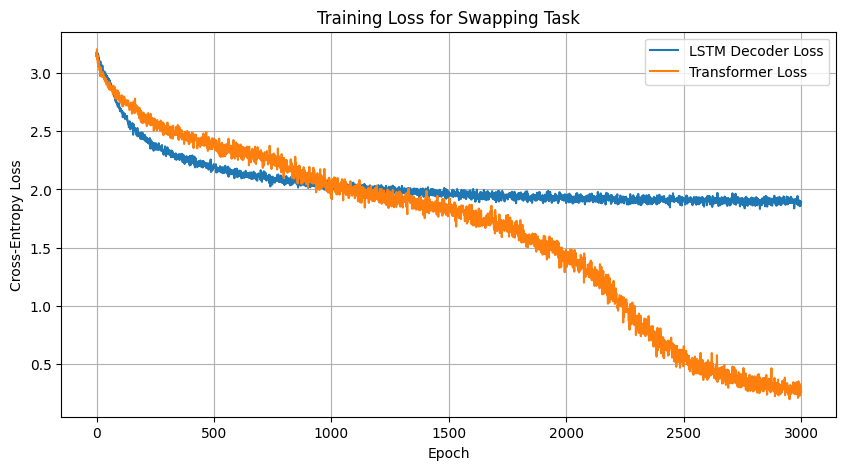

In [ ]:
# For Google Colab: set inline plotting
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import matplotlib.pyplot as plt
import os
import time

# -----------------------------
# Global Hyperparameters
# -----------------------------
VOCAB_SIZE    = 20        # tokens in [0, ..., 19]
SEQ_LENGTH    = 8         # sequence length
BATCH_SIZE    = 64
EPOCHS        = 3000       # for demonstration (increase if needed)
LR            = 1e-3
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# For the Transformer model we use these settings:
TRANS_EMBED_DIM         = 24
NHEAD                   = 2
NUM_ENCODER_LAYERS      = 1
NUM_DECODER_LAYERS      = 1
DIM_FEEDFORWARD         = 48
DROPOUT                 = 0.1

# For the original LSTM model we had HIDDEN_DIM = 32, EMBED_DIM = 16.
# To roughly double the LSTM model's parameter count (from ~7.5K to ~15K),
# we increase HIDDEN_DIM to approximately 50 (keeping EMBED_DIM the same).
LSTM_EMBED_DIM = 16
LSTM_HIDDEN_DIM = 50

# -----------------------------
# Data Generation for Swapping Task
# -----------------------------
def generate_batch_swap(batch_size, seq_length, vocab_size, device):
    """
    Generates random integer sequences and swaps the first and last tokens.
    Returns:
        src: (batch, seq_length) original sequences.
        swapped: (batch, seq_length) with first and last tokens swapped.
    """
    src = torch.randint(0, vocab_size, (batch_size, seq_length), device=device)
    swapped = src.clone()
    swapped[:, [0, -1]] = swapped[:, [-1, 0]]
    return src, swapped

# -----------------------------
# Teacher Forcing Helper for Transformer
# -----------------------------
def prepare_decoder_input(target, start_token=0):
    """
    Prepares the decoder input by shifting the target right and inserting a start token.
    """
    batch_size, seq_length = target.size()
    tgt_input = torch.zeros(batch_size, seq_length, dtype=torch.long, device=target.device)
    tgt_input[:, 0] = start_token
    tgt_input[:, 1:] = target[:, :-1]
    return tgt_input

# -----------------------------
# Simple LSTM Decoder (Doubled in Size)
# -----------------------------
class SimpleLSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, seq_length):
        super(SimpleLSTMDecoder, self).__init__()
        self.seq_length = seq_length
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim, hidden_dim)
        # Learned positional bias (one vector per output token position)
        self.pos_bias = nn.Parameter(torch.randn(seq_length, hidden_dim))
        self.decoder = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        batch_size = x.size(0)
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        c = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        for t in range(x.size(1)):
            emb = self.embedding(x[:, t])
            h, c = self.lstm_cell(emb, (h, c))
        # Only use the final hidden state; expand and add positional bias
        h_expanded = h.unsqueeze(1).expand(-1, self.seq_length, -1)
        logits = self.decoder(h_expanded + self.pos_bias)
        return logits

# -----------------------------
# Classic Transformer Model for Swapping Task
# -----------------------------
class TransformerSwapNet(nn.Module):
    def __init__(self, vocab_size, embed_dim, nhead, num_encoder_layers,
                 num_decoder_layers, dim_feedforward, dropout, max_seq_length):
        super(TransformerSwapNet, self).__init__()
        self.embed_src = nn.Embedding(vocab_size, embed_dim)
        self.embed_tgt = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=max_seq_length)
        self.pos_decoder = PositionalEncoding(embed_dim, max_len=max_seq_length)
        # Standard transformer expects input shape (seq_length, batch, embed_dim)
        self.transformer = nn.Transformer(
            d_model=embed_dim,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False
        )
        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def forward(self, src, tgt):
        # src and tgt: (batch, seq_length)
        src = src.transpose(0, 1)  # -> (seq_length, batch)
        tgt = tgt.transpose(0, 1)
        src_emb = self.embed_src(src) * math.sqrt(self.embed_src.embedding_dim)
        tgt_emb = self.embed_tgt(tgt) * math.sqrt(self.embed_tgt.embedding_dim)
        # Add positional encodings
        src_emb = self.pos_encoder(src_emb.transpose(0,1)).transpose(0,1)
        tgt_emb = self.pos_decoder(tgt_emb.transpose(0,1)).transpose(0,1)
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt_emb.size(0)).to(src.device)
        out = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask)
        out = self.fc_out(out)
        return out.transpose(0, 1)  # -> (batch, seq_length, vocab_size)

# -----------------------------
# Positional Encoding (shared by Transformer)
# -----------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)  # shape: (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # shape: (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_length, d_model)
        return x + self.pe[:, :x.size(1)]

# -----------------------------
# Training Routine for One Model
# -----------------------------
def train_model(model, optimizer, model_type="lstm", epochs=EPOCHS):
    loss_history = []
    for epoch in range(epochs):
        model.train()
        if model_type == "transformer":
            # For the transformer, we apply teacher forcing:
            src, target = generate_batch_swap(BATCH_SIZE, SEQ_LENGTH, VOCAB_SIZE, DEVICE)
            tgt_input = prepare_decoder_input(target, start_token=0)
            logits = model(src, tgt_input)
        else:
            # For the LSTM model, the forward pass takes only x:
            src, target = generate_batch_swap(BATCH_SIZE, SEQ_LENGTH, VOCAB_SIZE, DEVICE)
            logits = model(src)
        # Use reshape() to ensure proper tensor shape (avoid view() issues).
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")
    return loss_history

# -----------------------------
# Evaluation Function (Token & Sequence Accuracy)
# -----------------------------
def evaluate_model(model, model_type="lstm", n_batches=10):
    model.eval()
    total_tokens = 0
    correct_tokens = 0
    total_seqs = 0
    correct_seqs = 0
    with torch.no_grad():
        for _ in range(n_batches):
            if model_type == "transformer":
                src, target = generate_batch_swap(BATCH_SIZE, SEQ_LENGTH, VOCAB_SIZE, DEVICE)
                tgt_input = prepare_decoder_input(target, start_token=0)
                logits = model(src, tgt_input)
            else:
                src, target = generate_batch_swap(BATCH_SIZE, SEQ_LENGTH, VOCAB_SIZE, DEVICE)
                logits = model(src)
            preds = logits.argmax(dim=-1)
            total_tokens += target.numel()
            correct_tokens += (preds == target).sum().item()
            total_seqs += BATCH_SIZE
            correct_seqs += (preds == target).all(dim=1).sum().item()
    token_acc = correct_tokens / total_tokens * 100
    seq_acc = correct_seqs / total_seqs * 100
    return token_acc, seq_acc

# -----------------------------
# Instantiate Models and Optimizers
# -----------------------------
lstm_model = SimpleLSTMDecoder(VOCAB_SIZE, LSTM_EMBED_DIM, LSTM_HIDDEN_DIM, SEQ_LENGTH).to(DEVICE)
transformer_model = TransformerSwapNet(
    vocab_size=VOCAB_SIZE,
    embed_dim=TRANS_EMBED_DIM,
    nhead=NHEAD,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_seq_length=SEQ_LENGTH
).to(DEVICE)

optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=LR)
optimizer_transformer = optim.Adam(transformer_model.parameters(), lr=LR)

# Print parameter counts
lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
trans_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f"Simple LSTM Decoder Parameters: {lstm_params}")
print(f"Classic Transformer Parameters : {trans_params}")

# -----------------------------
# Training Both Models
# -----------------------------
print("\nTraining Simple LSTM Decoder (Swapping Task)...")
lstm_loss = train_model(lstm_model, optimizer_lstm, model_type="lstm", epochs=EPOCHS)
print("\nTraining Classic Transformer (Swapping Task)...")
transformer_loss = train_model(transformer_model, optimizer_transformer, model_type="transformer", epochs=EPOCHS)

# -----------------------------
# Evaluate Final Performance
# -----------------------------
lstm_token_acc, lstm_seq_acc = evaluate_model(lstm_model, model_type="lstm", n_batches=50)
trans_token_acc, trans_seq_acc = evaluate_model(transformer_model, model_type="transformer", n_batches=50)
print("\nFinal Evaluation:")
print(f"Simple LSTM Decoder - Token Acc: {lstm_token_acc:.2f}%, Sequence Acc: {lstm_seq_acc:.2f}%")
print(f"Classic Transformer  - Token Acc: {trans_token_acc:.2f}%, Sequence Acc: {trans_seq_acc:.2f}%")

# -----------------------------
# Plot Training Loss Curves
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(lstm_loss, label="LSTM Decoder Loss")
plt.plot(transformer_loss, label="Transformer Loss")
plt.title("Training Loss for Swapping Task")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!pip install ace_tools

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import time

# -----------------------------
# Hyperparameters and Device
# -----------------------------
VOCAB_SIZE   = 20
BATCH_SIZE   = 64
SEQ_LENGTH   = 8
LR           = 1e-3
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformer-specific
TRANS_EMBED_DIM = 24
NHEAD = 2
NUM_ENCODER_LAYERS = 1
NUM_DECODER_LAYERS = 1
DIM_FEEDFORWARD = 48
DROPOUT = 0.1

# Memory model–specific
MEMORY_EMBED_DIM = 16
HIDDEN_DIM = 32
NUM_HEADS = 4

# -----------------------------
# Data Generation Functions
# -----------------------------
def generate_batch_sort(batch_size, seq_length, vocab_size, device):
    src = torch.randint(0, vocab_size, (batch_size, seq_length), device=device)
    sorted_seq, _ = torch.sort(src, dim=1)
    return src, sorted_seq

def generate_batch_swap(batch_size, seq_length, vocab_size, device):
    src = torch.randint(0, vocab_size, (batch_size, seq_length), device=device)
    swapped = src.clone()
    swapped[:, [0, -1]] = swapped[:, [-1, 0]]
    return src, swapped

# Standard teacher forcing: shift right and prepend a start token (0)
def prepare_decoder_input(target, start_token=0):
    batch_size, seq_length = target.size()
    tgt_input = torch.zeros(batch_size, seq_length, dtype=torch.long, device=target.device)
    tgt_input[:, 0] = start_token
    tgt_input[:, 1:] = target[:, :-1]
    return tgt_input

# Alternative teacher forcing: for tasks like swapping,
# feed the target sequence directly as decoder input.
def prepare_decoder_input_identity(target):
    return target.clone()

# -----------------------------
# Positional Encoding (Transformer)
# -----------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        # Using available dimensions for cosine, if needed
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# -----------------------------
# Transformer Model (for both tasks)
# -----------------------------
class FixedTransformerSortNet(nn.Module):
    def __init__(self, vocab_size, embed_dim, nhead, num_encoder_layers,
                 num_decoder_layers, dim_feedforward, dropout, max_seq_length):
        super().__init__()
        self.embed_src = nn.Embedding(vocab_size, embed_dim)
        self.embed_tgt = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=max_seq_length)
        self.pos_decoder = PositionalEncoding(embed_dim, max_len=max_seq_length)
        self.transformer = nn.Transformer(
            d_model=embed_dim,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False
        )
        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def forward(self, src, tgt):
        # src, tgt: (batch, seq_length)
        src = src.transpose(0, 1)  # (seq_length, batch)
        tgt = tgt.transpose(0, 1)
        src_emb = self.embed_src(src) * math.sqrt(self.embed_src.embedding_dim)
        tgt_emb = self.embed_tgt(tgt) * math.sqrt(self.embed_tgt.embedding_dim)
        src_emb = self.pos_encoder(src_emb.transpose(0, 1)).transpose(0, 1)
        tgt_emb = self.pos_decoder(tgt_emb.transpose(0, 1)).transpose(0, 1)
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt_emb.size(0)).to(src.device)
        out = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask)
        out = self.fc_out(out)
        return out.transpose(0, 1)  # shape: (batch, seq_length, vocab_size)

# -----------------------------
# Memory Model (for both tasks)
# -----------------------------
class MemoryEncoderDecoderNet(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_heads, seq_length):
        super().__init__()
        self.seq_length = seq_length
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim, hidden_dim)
        self.attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.pos_bias = nn.Parameter(torch.randn(seq_length, hidden_dim))
        self.decoder = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.size()
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        c = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        hidden_history = []
        for t in range(seq_len):
            token = x[:, t]
            emb = self.embedding(token)
            h, c = self.lstm_cell(emb, (h, c))
            hidden_history.append(h)
            memory = torch.stack(hidden_history, dim=1)  # shape: (batch, t+1, hidden_dim)
            query = h.unsqueeze(1)  # shape: (batch, 1, hidden_dim)
            attn_out, _ = self.attn(query=query, key=memory, value=memory)
            h = h + attn_out[:, 0, :]  # residual connection
        h_expanded = h.unsqueeze(1).expand(-1, self.seq_length, -1)
        out_repr = h_expanded + self.pos_bias
        logits = self.decoder(out_repr)
        return logits  # shape: (batch, seq_length, vocab_size)

# -----------------------------
# Mini Overfitting Test Functions
# -----------------------------
def mini_overfit_test_transformer(model, optimizer, batch_gen, seq_length, teacher_forcing_mode='default'):
    """
    Train the transformer on a single batch repeatedly to check if it can overfit.
    teacher_forcing_mode: 'default' uses shifting with a start token;
                          'identity' simply passes the target as decoder input.
    """
    model.train()
    src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
    if teacher_forcing_mode == 'default':
        tgt_input = prepare_decoder_input(target, start_token=0)
    elif teacher_forcing_mode == 'identity':
        tgt_input = prepare_decoder_input_identity(target)
    else:
        raise ValueError("Unknown teacher_forcing_mode")

    print(f"\n==== Mini Overfitting Test for Transformer on swapping task with teacher forcing mode = {teacher_forcing_mode} ====")
    for i in range(100):
        optimizer.zero_grad()
        output = model(src, tgt_input)
        loss = F.cross_entropy(output.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        loss.backward()
        optimizer.step()
        if i % 10 == 0:
            print(f"Step {i:3d}: loss = {loss.item():.4f}")
    print("Final mini-overfit loss:", loss.item())
    return loss.item()

def mini_overfit_test_memory(model, optimizer, batch_gen, seq_length):
    """
    Train the memory model on a single batch repeatedly.
    (Teacher forcing doesn't apply here since there's no shifting.)
    """
    model.train()
    src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
    print(f"\n==== Mini Overfitting Test for Memory Model on swapping task ====")
    for i in range(100):
        optimizer.zero_grad()
        output = model(src)
        loss = F.cross_entropy(output.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        loss.backward()
        optimizer.step()
        if i % 10 == 0:
            print(f"Step {i:3d}: loss = {loss.item():.4f}")
    print("Final mini-overfit loss:", loss.item())
    return loss.item()

# -----------------------------
# Per-Token Debugging Utilities
# -----------------------------
def debug_token_loss(model, batch_gen, seq_length, task_name, model_type='transformer', teacher_forcing_mode='default'):
    """
    Evaluate and print the average cross-entropy loss at each token position.
    """
    model.eval()
    if model_type == 'transformer':
        src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
        if teacher_forcing_mode == 'default':
            tgt_input = prepare_decoder_input(target, start_token=0)
        elif teacher_forcing_mode == 'identity':
            tgt_input = prepare_decoder_input_identity(target)
        else:
            raise ValueError("Unknown teacher_forcing_mode")
        output = model(src, tgt_input)
    else:
        src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
        output = model(src)

    losses = []
    for pos in range(seq_length):
        logits_pos = output[:, pos, :]
        target_pos = target[:, pos]
        loss_pos = F.cross_entropy(logits_pos, target_pos, reduction='mean')
        losses.append(loss_pos.item())

    print(f"\n==== Per-Token Loss for {model_type.capitalize()} on {task_name} Task ====")
    for pos, loss_val in enumerate(losses):
        print(f"Token Position {pos}: Loss = {loss_val:.4f}")

def debug_token_accuracy(model, batch_gen, seq_length, task_name, model_type='transformer', teacher_forcing_mode='default'):
    """
    Compute and print the accuracy at each token position.
    """
    model.eval()
    if model_type == 'transformer':
        src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
        if teacher_forcing_mode == 'default':
            tgt_input = prepare_decoder_input(target, start_token=0)
        elif teacher_forcing_mode == 'identity':
            tgt_input = prepare_decoder_input_identity(target)
        else:
            raise ValueError("Unknown teacher_forcing_mode")
        output = model(src, tgt_input)
    else:
        src, target = batch_gen(BATCH_SIZE, seq_length, VOCAB_SIZE, DEVICE)
        output = model(src)

    preds = output.argmax(dim=-1)  # (batch, seq_length)
    accuracies = []
    for pos in range(seq_length):
        correct = (preds[:, pos] == target[:, pos]).sum().item()
        acc = correct / target.size(0)
        accuracies.append(acc)

    print(f"\n==== Per-Token Accuracy for {model_type.capitalize()} on {task_name} Task ====")
    for pos, acc in enumerate(accuracies):
        print(f"Token Position {pos}: Accuracy = {acc*100:.2f}%")

# -----------------------------
# Main Debug Routine for Swapping Task
# -----------------------------
if __name__ == '__main__':
    torch.manual_seed(42)  # for reproducibility

    print("***** Debugging Swapping Task *****")

    # Instantiate models for swapping task (Transformer & Memory)
    transformer_swap_model = FixedTransformerSortNet(
        vocab_size=VOCAB_SIZE,
        embed_dim=TRANS_EMBED_DIM,
        nhead=NHEAD,
        num_encoder_layers=NUM_ENCODER_LAYERS,
        num_decoder_layers=NUM_DECODER_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        dropout=DROPOUT,
        max_seq_length=SEQ_LENGTH
    ).to(DEVICE)

    memory_swap_model = MemoryEncoderDecoderNet(
        vocab_size=VOCAB_SIZE,
        embed_dim=MEMORY_EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_heads=NUM_HEADS,
        seq_length=SEQ_LENGTH
    ).to(DEVICE)

    # Optimizers for the models
    opt_trans_swap = optim.Adam(transformer_swap_model.parameters(), lr=LR)
    opt_mem_swap = optim.Adam(memory_swap_model.parameters(), lr=LR)

    # Run mini-overfitting tests with the standard teacher forcing strategy
    loss_default = mini_overfit_test_transformer(transformer_swap_model, opt_trans_swap,
                                                   generate_batch_swap, SEQ_LENGTH,
                                                   teacher_forcing_mode='default')
    loss_identity = mini_overfit_test_transformer(transformer_swap_model, opt_trans_swap,
                                                    generate_batch_swap, SEQ_LENGTH,
                                                    teacher_forcing_mode='identity')

    # Run mini-overfitting test for Memory model (teacher forcing doesn't apply)
    loss_mem = mini_overfit_test_memory(memory_swap_model, opt_mem_swap,
                                        generate_batch_swap, SEQ_LENGTH)

    # Print per-token diagnostics for Transformer with both modes:
    print("\n--- Transformer with Default Teacher Forcing ---")
    debug_token_loss(transformer_swap_model, generate_batch_swap, SEQ_LENGTH,
                     task_name="swapping", model_type="transformer", teacher_forcing_mode='default')
    debug_token_accuracy(transformer_swap_model, generate_batch_swap, SEQ_LENGTH,
                         task_name="swapping", model_type="transformer", teacher_forcing_mode='default')

    print("\n--- Transformer with Identity Teacher Forcing ---")
    debug_token_loss(transformer_swap_model, generate_batch_swap, SEQ_LENGTH,
                     task_name="swapping", model_type="transformer", teacher_forcing_mode='identity')
    debug_token_accuracy(transformer_swap_model, generate_batch_swap, SEQ_LENGTH,
                         task_name="swapping", model_type="transformer", teacher_forcing_mode='identity')


***** Debugging Swapping Task *****


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(



==== Mini Overfitting Test for Transformer on swapping task with teacher forcing mode = default ====
Step   0: loss = 3.1868
Step  10: loss = 2.9837
Step  20: loss = 2.8627
Step  30: loss = 2.7858
Step  40: loss = 2.6957
Step  50: loss = 2.6044
Step  60: loss = 2.5073
Step  70: loss = 2.4327
Step  80: loss = 2.3503
Step  90: loss = 2.2289
Final mini-overfit loss: 2.1471192836761475

==== Mini Overfitting Test for Transformer on swapping task with teacher forcing mode = identity ====
Step   0: loss = 3.3161
Step  10: loss = 2.4533
Step  20: loss = 1.8243
Step  30: loss = 1.3647
Step  40: loss = 1.0325
Step  50: loss = 0.7770
Step  60: loss = 0.5893
Step  70: loss = 0.4586
Step  80: loss = 0.3624
Step  90: loss = 0.2870
Final mini-overfit loss: 0.23509539663791656

==== Mini Overfitting Test for Memory Model on swapping task ====
Step   0: loss = 3.1871
Step  10: loss = 3.0883
Step  20: loss = 3.0085
Step  30: loss = 2.9377
Step  40: loss = 2.8611
Step  50: loss = 2.7635
Step  60: loss 